In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alitaqishah/blood-cell-anomaly-detection-2025")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'blood-cell-anomaly-detection-2025' dataset.
Path to dataset files: /kaggle/input/blood-cell-anomaly-detection-2025



--- Đang xử lý: Nhóm A: Hình thái & Bệnh lý (Tín hiệu Vàng) ---


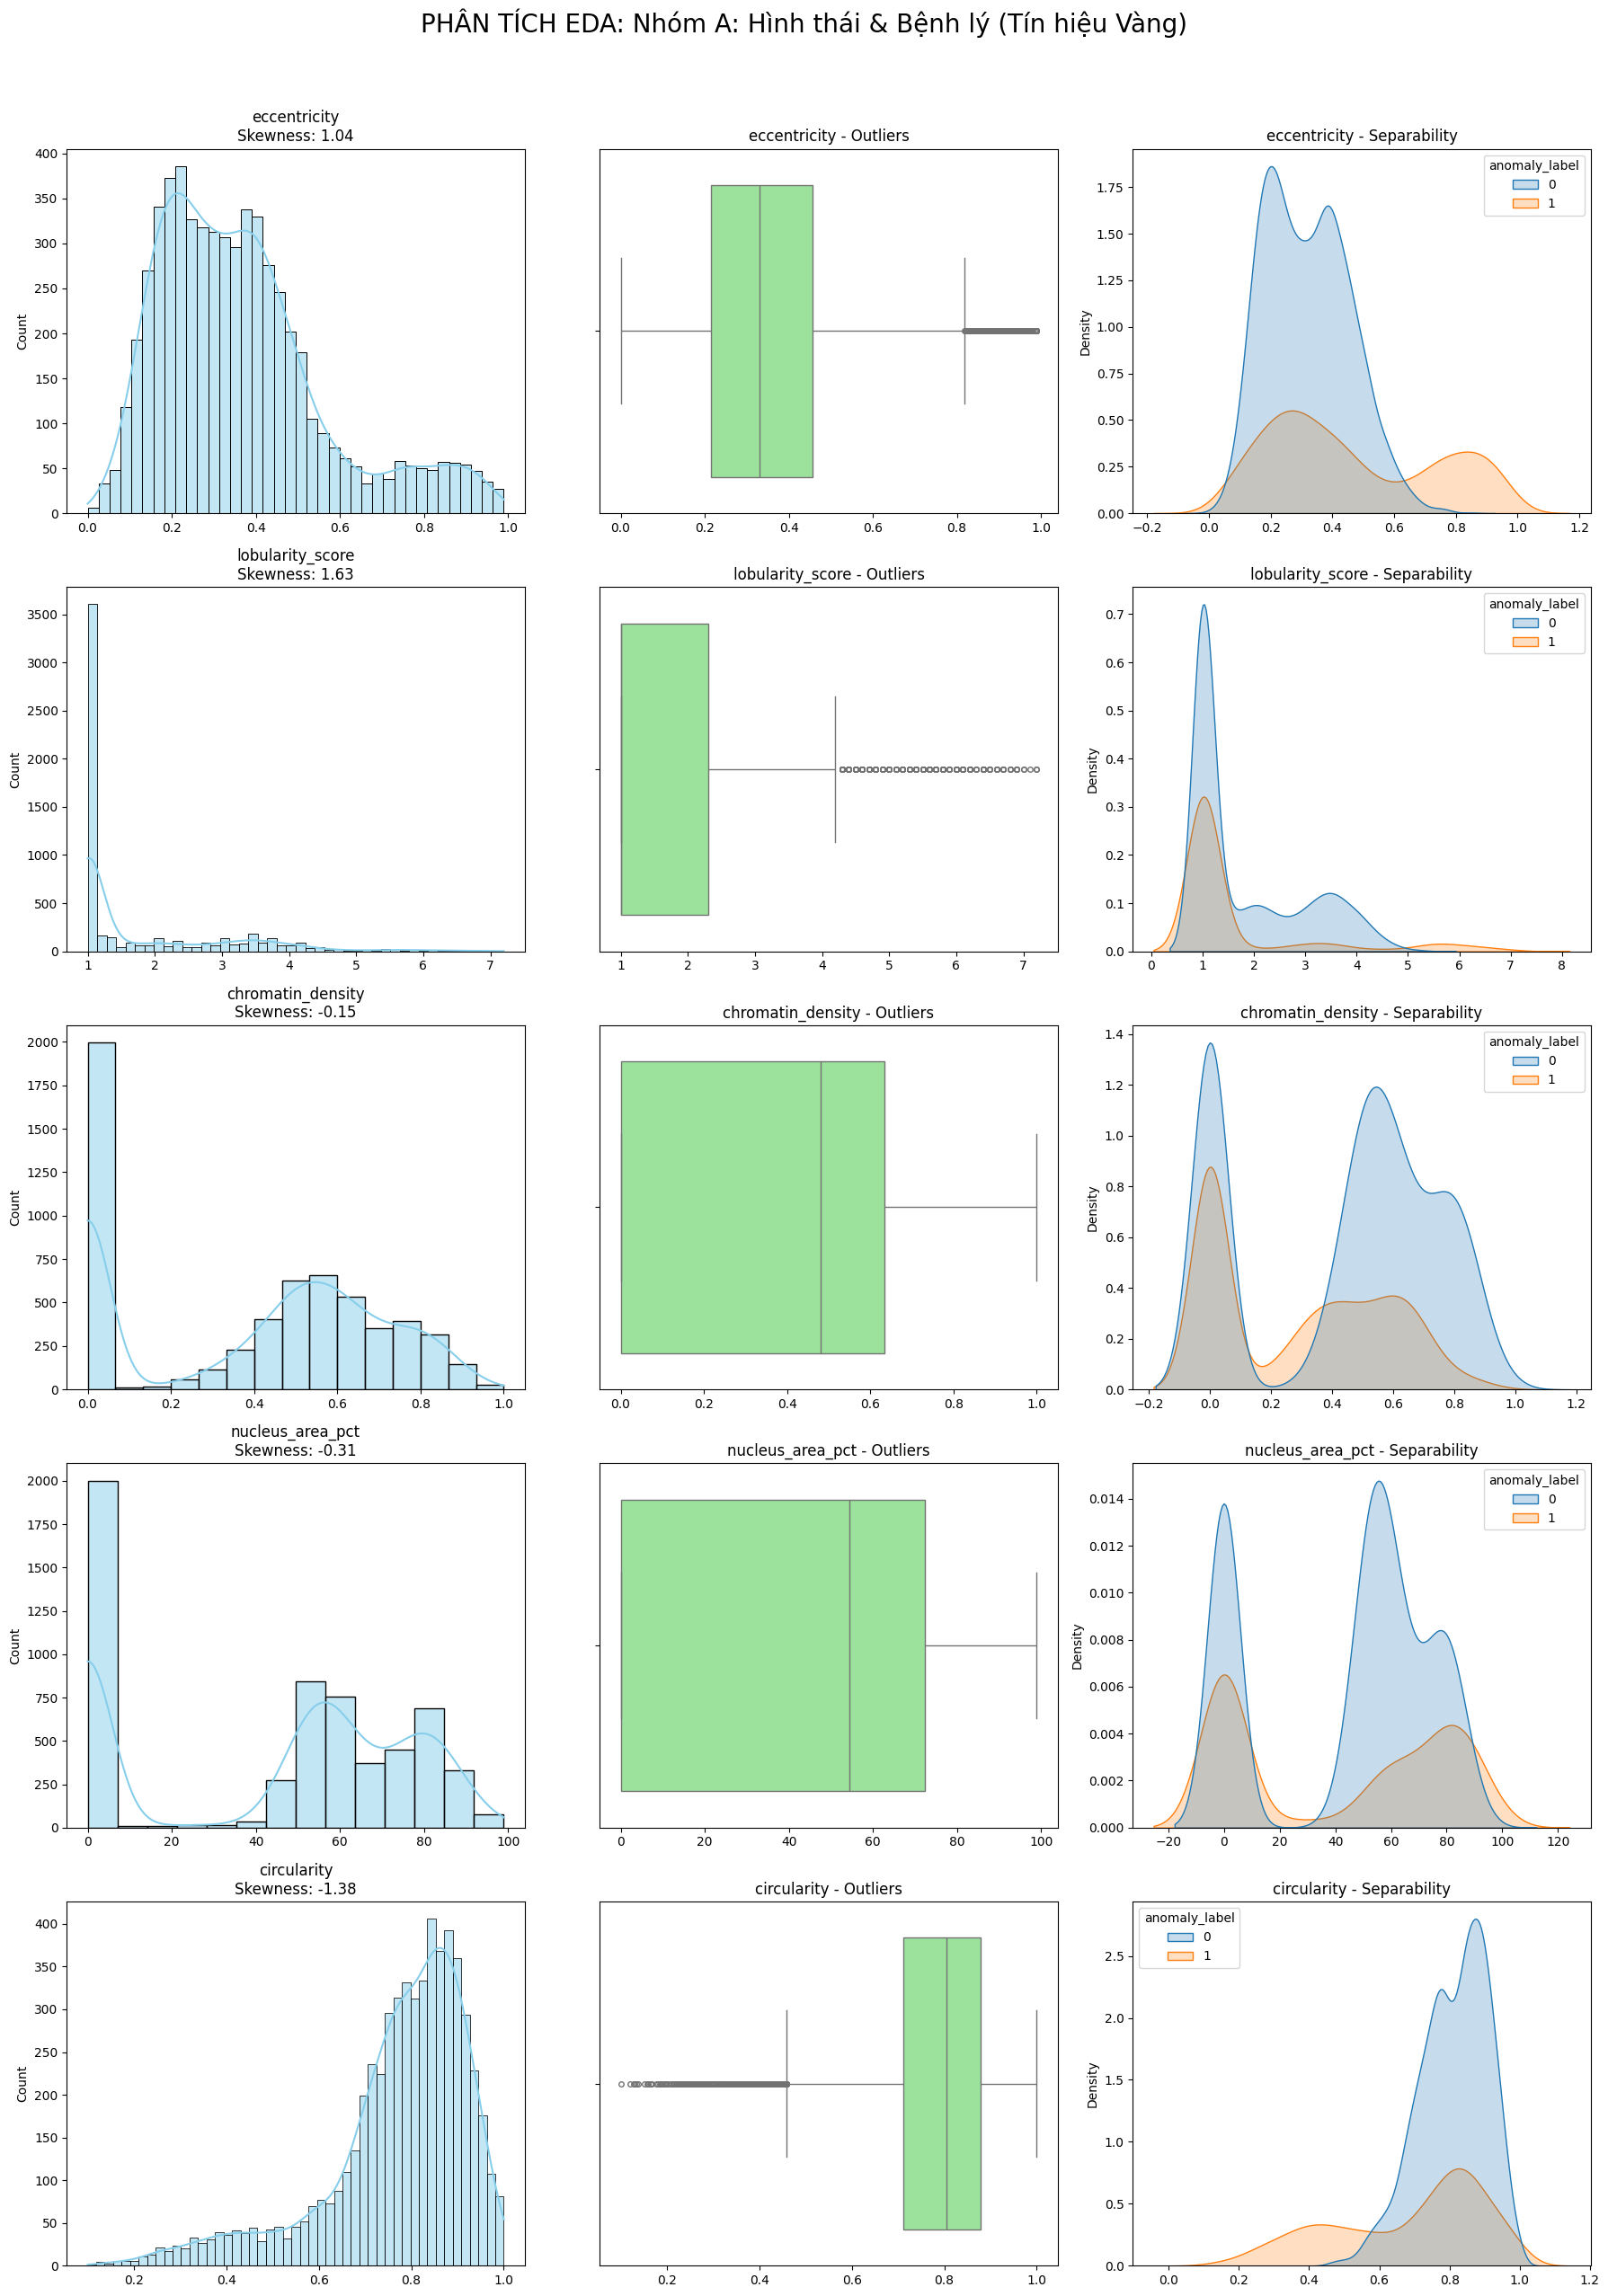


--- Đang xử lý: Nhóm B: Hình thái học (Cần xử lý Skewness) ---


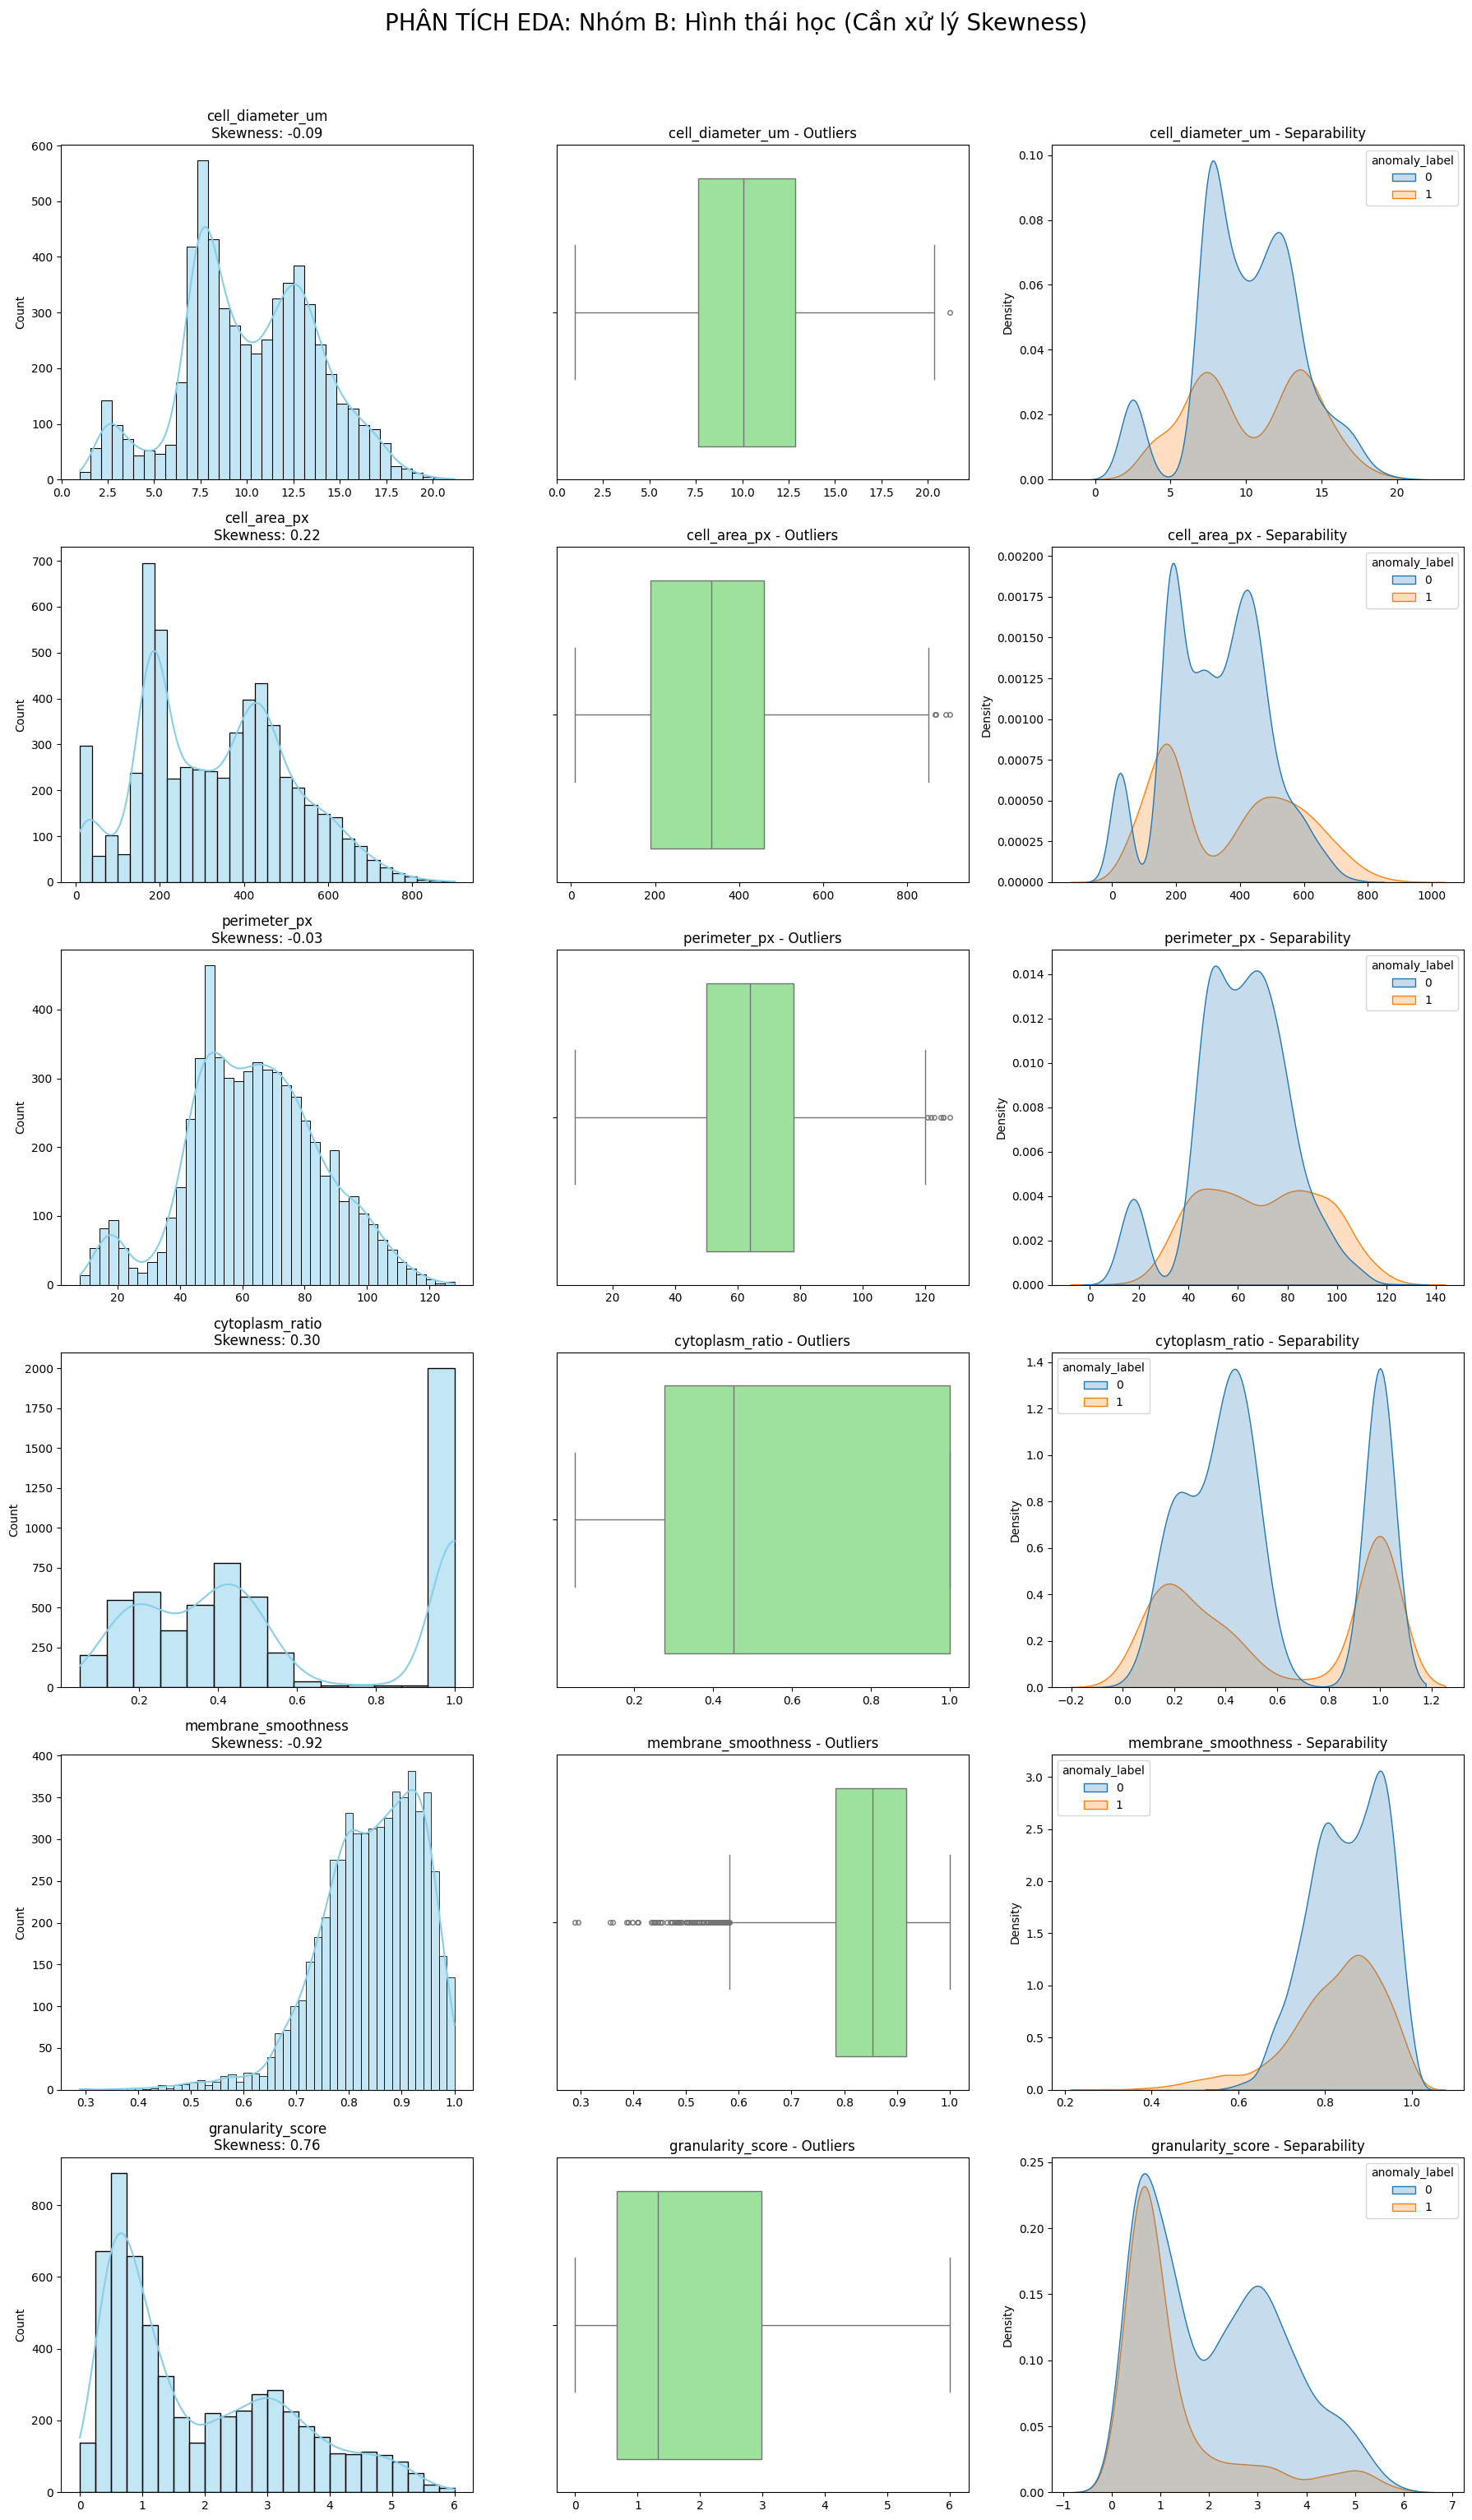


--- Đang xử lý: Nhóm C: Chỉ số Huyết học & Nhiễu kỹ thuật ---


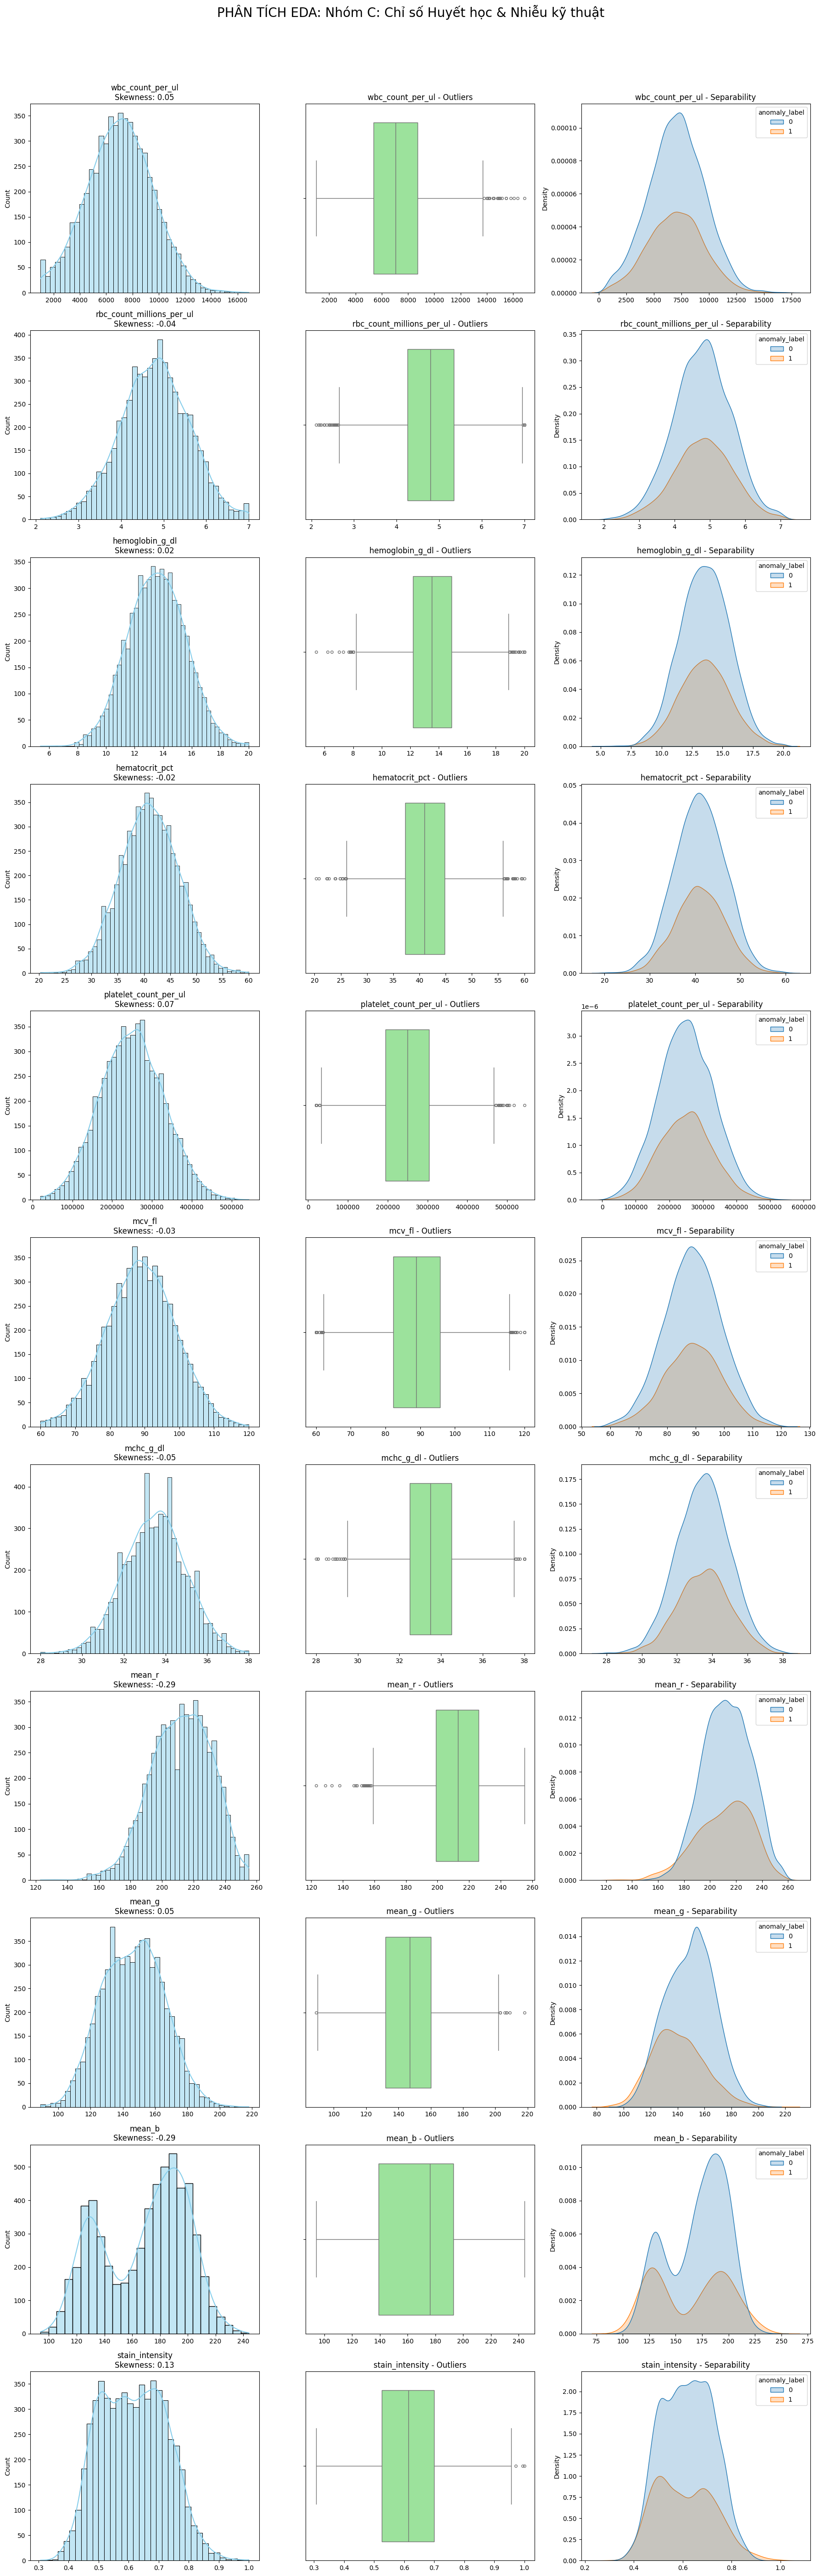


--- Đang xử lý: Nhóm D: Điểm tin cậy & Thuật toán ---


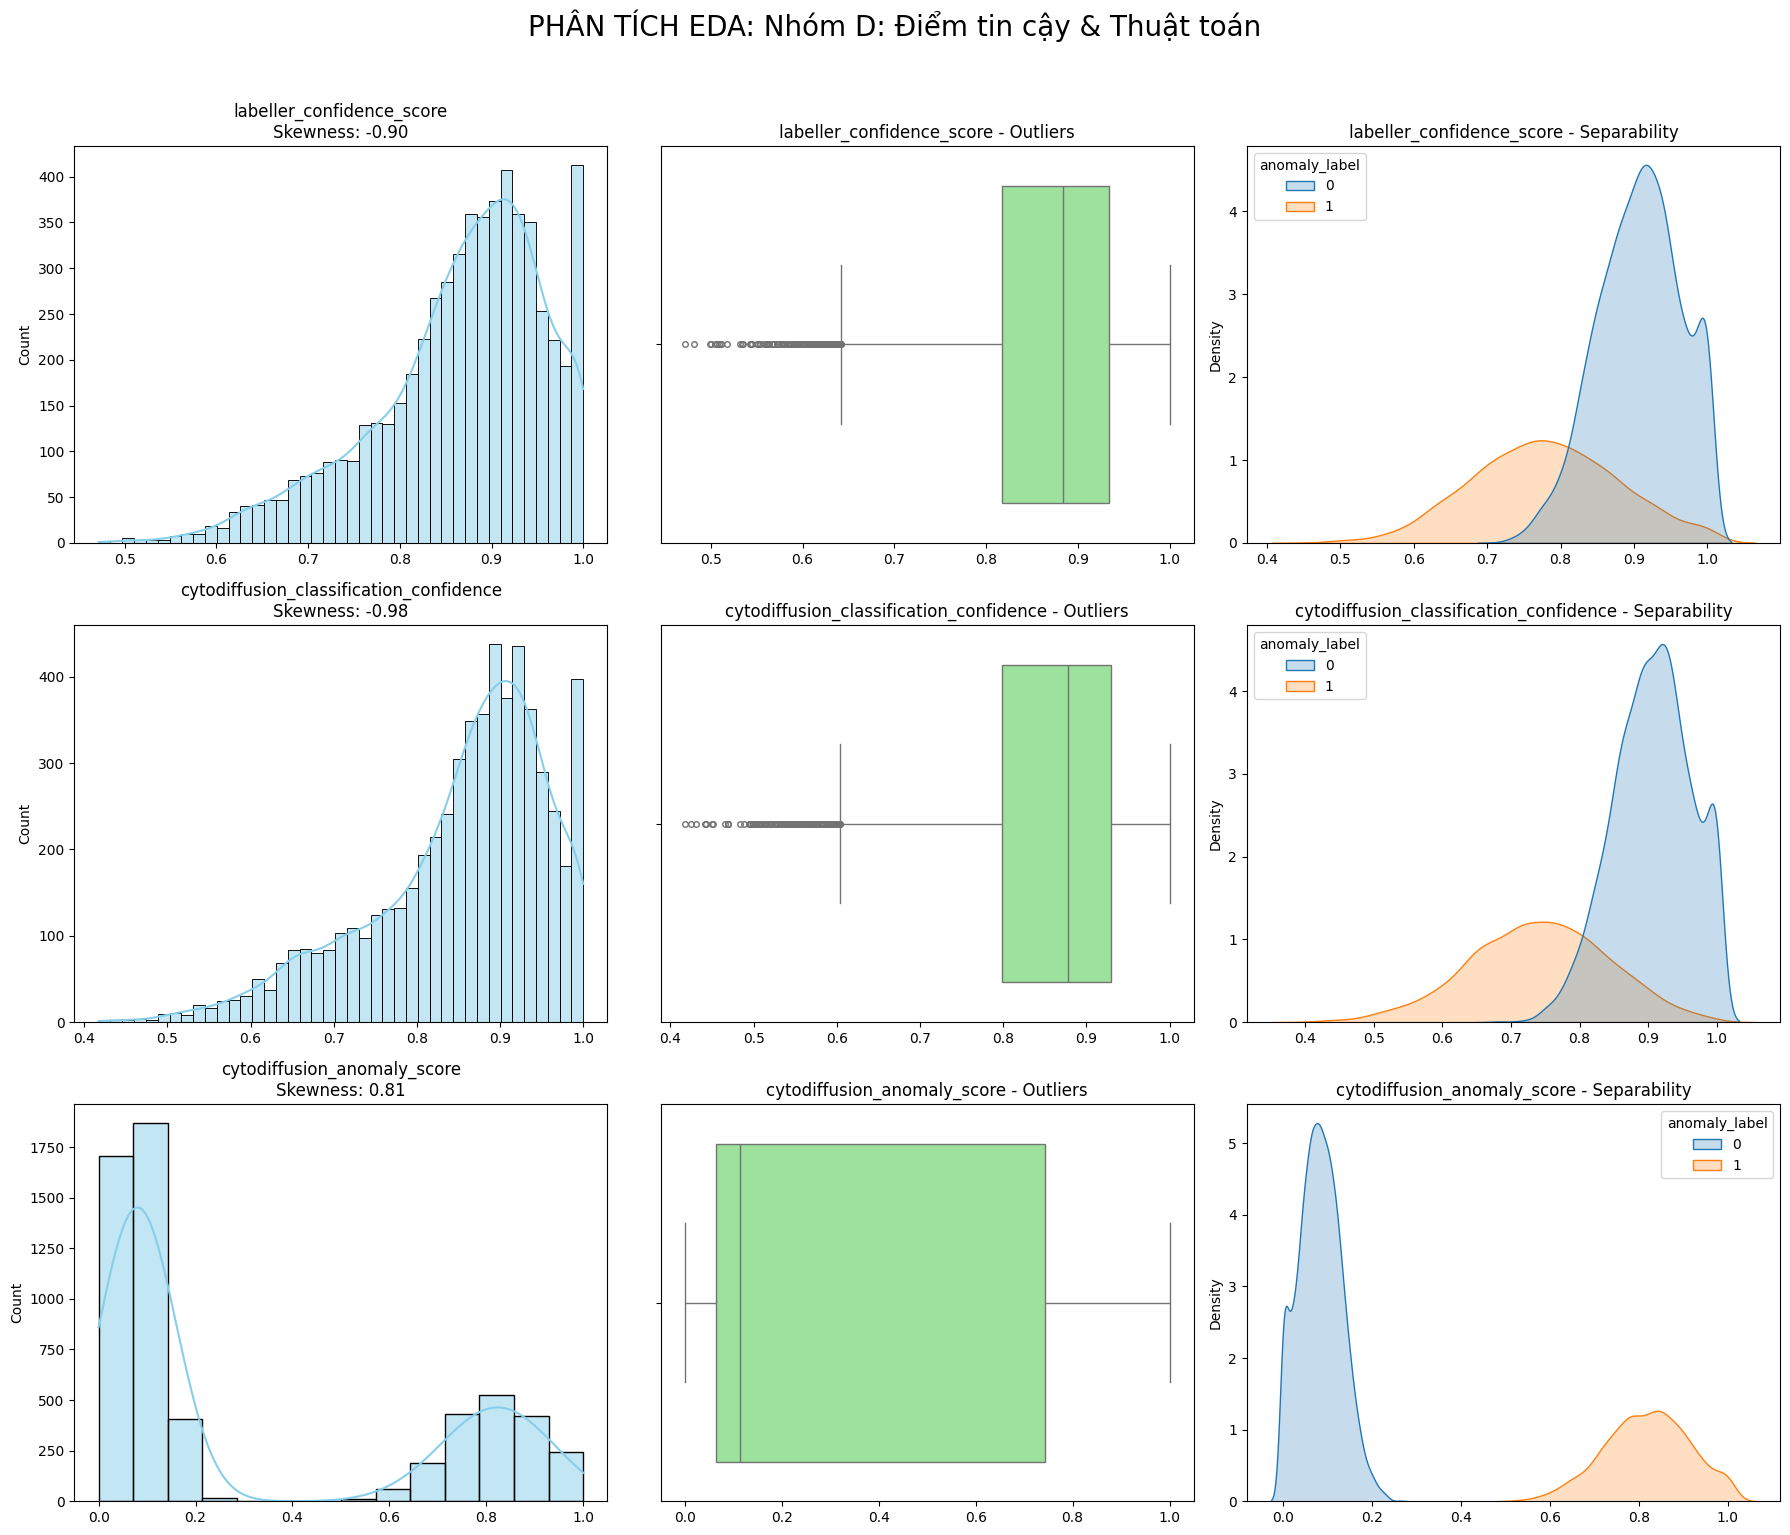

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

df = pd.read_csv("/kaggle/input/blood-cell-anomaly-detection-2025/blood_cell_anomaly_detection.csv")

# 1. ĐỊNH NGHĨA CÁC NHÓM BIẾN (Dựa trên phân tích trước đó)
groups = {
    "Nhóm A: Hình thái & Bệnh lý (Tín hiệu Vàng)": [
        'eccentricity', 'lobularity_score', 'chromatin_density',
        'nucleus_area_pct', 'circularity'
    ],
    "Nhóm B: Hình thái học (Cần xử lý Skewness)": [
        'cell_diameter_um', 'cell_area_px', 'perimeter_px',
        'cytoplasm_ratio', 'membrane_smoothness', 'granularity_score'
    ],
    "Nhóm C: Chỉ số Huyết học & Nhiễu kỹ thuật": [
        'wbc_count_per_ul', 'rbc_count_millions_per_ul', 'hemoglobin_g_dl',
        'hematocrit_pct', 'platelet_count_per_ul', 'mcv_fl', 'mchc_g_dl',
        'mean_r', 'mean_g', 'mean_b', 'stain_intensity'
    ],
    "Nhóm D: Điểm tin cậy & Thuật toán": [
        'labeller_confidence_score', 'cytodiffusion_classification_confidence',
        'cytodiffusion_anomaly_score'
    ]
}

def plot_eda_by_group(df, feature_list, group_name, target='anomaly_label'):
    """
    Vẽ 3 biểu đồ: Distribution(Skewness), Boxplot(Outlier), KDE(Separability) cho mỗi biến.
    """
    print(f"\n--- Đang xử lý: {group_name} ---")

    num_features = len(feature_list)
    # Thiết lập lưới đồ thị: Mỗi biến 1 hàng, 3 cột
    fig, axes = plt.subplots(num_features, 3, figsize=(18, 5 * num_features))

    # Trường hợp chỉ có 1 biến trong nhóm
    if num_features == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, col in enumerate(feature_list):
        # Tính độ lệch (Skewness)
        current_skew = skew(df[col].dropna())

        # Biểu đồ 1: Distribution & Skewness
        sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
        axes[i, 0].set_title(f"{col}\nSkewness: {current_skew:.2f}")
        axes[i, 0].set_xlabel("")

        # Biểu đồ 2: Boxplot (Xác định Outliers)
        sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen', fliersize=4)
        axes[i, 1].set_title(f"{col} - Outliers")
        axes[i, 1].set_xlabel("")

        # Biểu đồ 3: KDE Plot theo Target (Khả năng phân loại)
        # Kiểm tra xem có đủ 2 nhãn để vẽ không
        if df[target].nunique() > 1:
            sns.kdeplot(data=df, x=col, hue=target, fill=True, ax=axes[i, 2], palette='tab10')
            axes[i, 2].set_title(f"{col} - Separability")
        else:
            axes[i, 2].text(0.5, 0.5, 'Target duy nhất', ha='center')
        axes[i, 2].set_xlabel("")

    plt.suptitle(f"PHÂN TÍCH EDA: {group_name}", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

# 2. THỰC THI VẼ CHO TỪNG NHÓM
# Bạn có thể chạy từng dòng dưới đây để xem kết quả từng nhóm
for g_name, f_list in groups.items():
    # Kiểm tra xem các cột có tồn tại trong df không để tránh lỗi
    available_features = [f for f in f_list if f in df.columns]
    if available_features:
        plot_eda_by_group(df, available_features, g_name)